### KNN con DATASET REAL (Iris) — Notebook ilustrativo con gráficos


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score

np.random.seed(42)

### 1) Cargar dataset real: Iris


In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(lambda i: iris.target_names[i])

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
list(df.columns)

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)',
 'target',
 'species']

### 2) Visualización inicial (pares de variables)


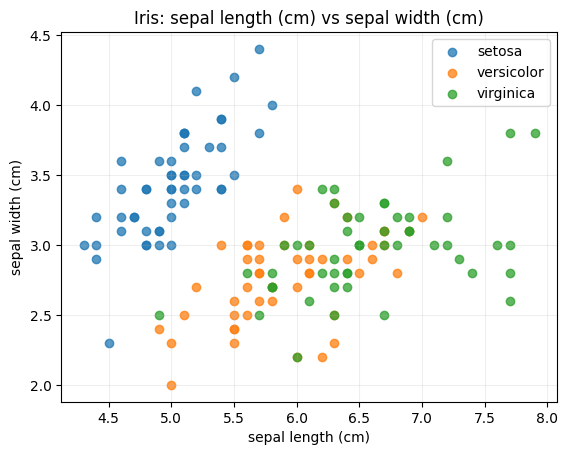

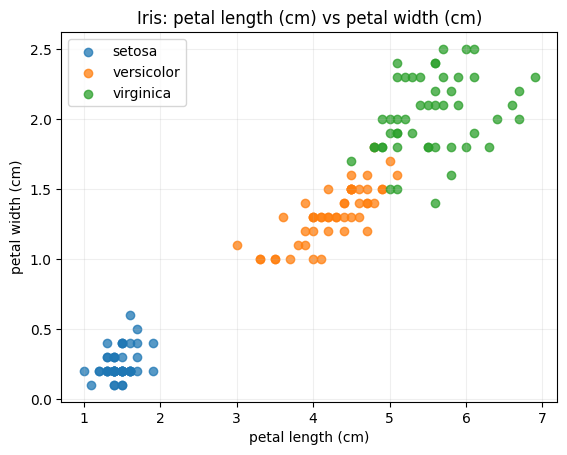

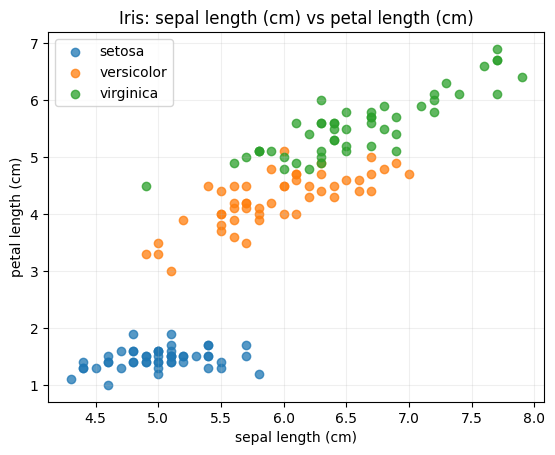

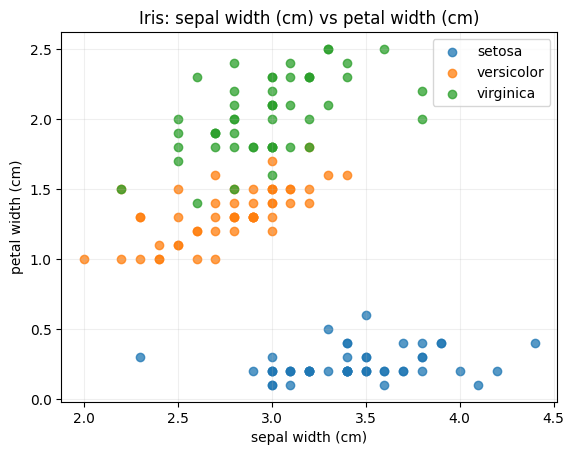

In [ ]:
pairs = [
    ("sepal length (cm)", "sepal width (cm)"),
    ("petal length (cm)", "petal width (cm)"),
    ("sepal length (cm)", "petal length (cm)"),
    ("sepal width (cm)", "petal width (cm)")
]

for xcol, ycol in pairs:
    plt.figure()
    for sp in df["species"].unique():
        sub = df[df["species"] == sp]
        plt.scatter(sub[xcol], sub[ycol], label=sp, alpha=0.75)
    plt.title(f"Iris: {xcol} vs {ycol}")
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

### 3) Preparar X, y (4D) + Train/Test + Estandarizar


In [5]:
X = df[iris.feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("X_train shape:", X_train_s.shape, "| X_test shape:", X_test_s.shape)

X_train shape: (112, 4) | X_test shape: (38, 4)


### 4) Entrenar KNN en 4D (modelo REAL)


In [6]:
k = 7
knn4d = KNeighborsClassifier(n_neighbors=k)
knn4d.fit(X_train_s, y_train)

y_pred = knn4d.predict(X_test_s)
acc = accuracy_score(y_test, y_pred)

print(f"k = {k}")
print(f"Accuracy test = {acc:.3f}")

k = 7
Accuracy test = 0.947


### 5) Evaluación (matriz de confusión + reporte)


<Figure size 640x480 with 0 Axes>

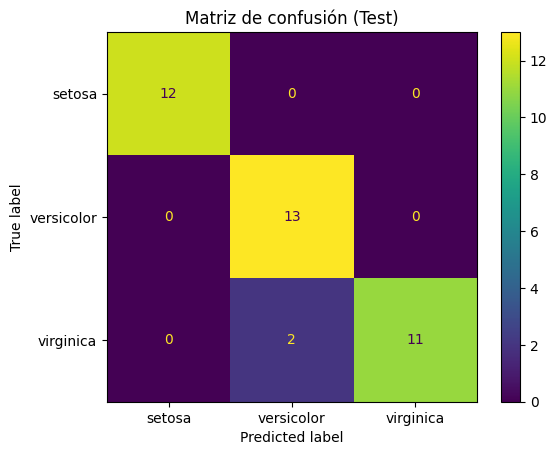

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.87      1.00      0.93        13
   virginica       1.00      0.85      0.92        13

    accuracy                           0.95        38
   macro avg       0.96      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



In [7]:
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=iris.target_names)
plt.title("Matriz de confusión (Test)")
plt.grid(False)
plt.show()

print(classification_report(y_test, y_pred, target_names=iris.target_names))

### 6) PCA a 2D para VISUALIZAR (explicar KNN en un plano)


In [8]:
#    OJO: Esto es para graficar, NO para "hacer trampa" (aunque se puede)


6) PCA a 2D para visualización
Varianza explicada por PCA(2): [0.73911238 0.22125712] | Total: 0.9603695045916796


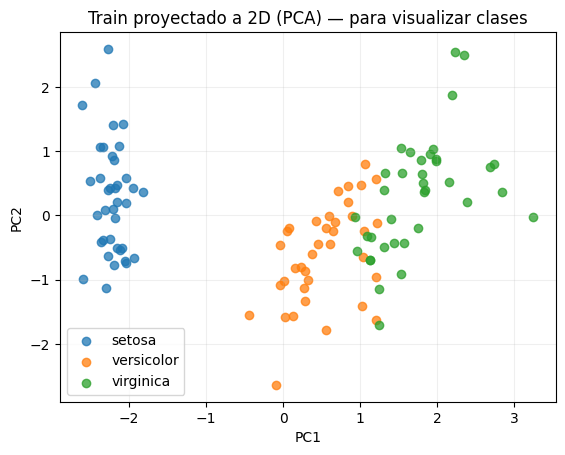

In [9]:
print("6) PCA a 2D para visualización")

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca  = pca.transform(X_test_s)

print("Varianza explicada por PCA(2):", pca.explained_variance_ratio_,
      "| Total:", pca.explained_variance_ratio_.sum())

plt.figure()
for c in np.unique(y_train):
    plt.scatter(X_train_pca[y_train==c, 0], X_train_pca[y_train==c, 1], label=iris.target_names[c], alpha=0.75)
plt.title("Train proyectado a 2D (PCA) — para visualizar clases")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()



### 7) KNN en 2D (PCA) SOLO para dibujar frontera y vecinos en el plano


In [10]:
#    Manteniendo el KNN 4D como “modelo real”.


7) KNN en 2D (PCA) para frontera/vecinos VISUALES


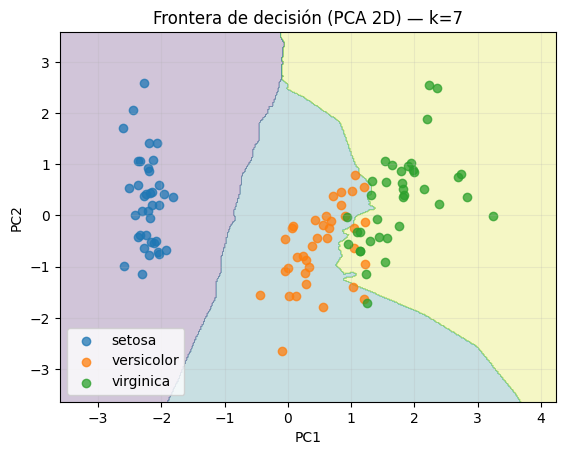

In [11]:
print("7) KNN en 2D (PCA) para frontera/vecinos VISUALES")

knn2d = KNeighborsClassifier(n_neighbors=k)
knn2d.fit(X_train_pca, y_train)

def plot_decision_boundary_2d(model, X2d, y, title_text="Frontera 2D", step=0.02):
    x_min, x_max = X2d[:, 0].min() - 1, X2d[:, 0].max() + 1
    y_min, y_max = X2d[:, 1].min() - 1, X2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, zz, alpha=0.25)
    for c in np.unique(y):
        plt.scatter(X2d[y==c, 0], X2d[y==c, 1], label=iris.target_names[c], alpha=0.75)
    plt.title(title_text)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

plot_decision_boundary_2d(knn2d, X_train_pca, y_train, title_text=f"Frontera de decisión (PCA 2D) — k={k}")



### 8) Vecinos de un punto (visual) + comparación con predicción REAL (4D)


### elegimos un ejemplo del test


8) Vecinos más cercanos (visual en PCA 2D) + predicción real 4D
Etiqueta real: setosa
Predicción KNN REAL (4D): setosa
Predicción KNN VISUAL (PCA 2D): setosa


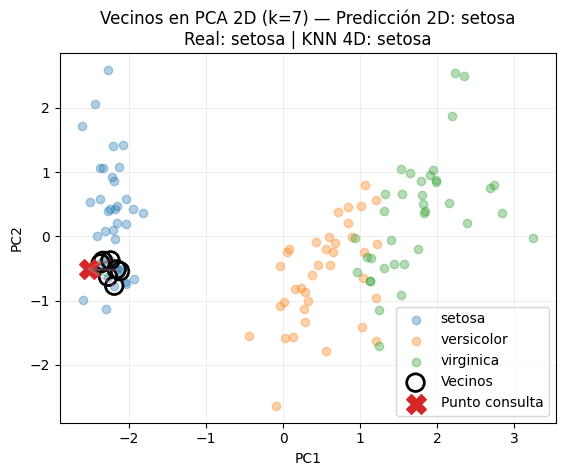

In [12]:
print("8) Vecinos más cercanos (visual en PCA 2D) + predicción real 4D")

def plot_neighbors_2d(knn_model_2d, X_train_2d, y_train, point_2d, k, subtitle=""):
    distances, indices = knn_model_2d.kneighbors([point_2d], n_neighbors=k, return_distance=True)
    idx = indices[0]
    d = distances[0]
    pred2d = knn_model_2d.predict([point_2d])[0]

    plt.figure()
    for c in np.unique(y_train):
        plt.scatter(X_train_2d[y_train==c, 0], X_train_2d[y_train==c, 1], alpha=0.35, label=iris.target_names[c])

    # vecinos
    plt.scatter(X_train_2d[idx, 0], X_train_2d[idx, 1], s=160, facecolors="none", edgecolors="black", linewidths=2, label="Vecinos")
    # punto consulta
    plt.scatter(point_2d[0], point_2d[1], s=200, marker="X", label="Punto consulta")

    # líneas a vecinos
    for i, di in zip(idx, d):
        plt.plot([point_2d[0], X_train_2d[i, 0]], [point_2d[1], X_train_2d[i, 1]], linewidth=1, alpha=0.5)

    plt.title(f"Vecinos en PCA 2D (k={k}) — Predicción 2D: {iris.target_names[pred2d]}\n{subtitle}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

idx_test = 0
point4d = X_test_s[idx_test]       # punto estandarizado en 4D
point2d = X_test_pca[idx_test]     # proyección PCA a 2D
true_label = y_test[idx_test]

pred4d = knn4d.predict([point4d])[0]
pred2d = knn2d.predict([point2d])[0]

print("Etiqueta real:", iris.target_names[true_label])
print("Predicción KNN REAL (4D):", iris.target_names[pred4d])
print("Predicción KNN VISUAL (PCA 2D):", iris.target_names[pred2d])

plot_neighbors_2d(
    knn2d, X_train_pca, y_train, point2d, k,
    subtitle=f"Real: {iris.target_names[true_label]} | KNN 4D: {iris.target_names[pred4d]}"
)



### 9) Efecto de k: comparar accuracy y fronteras (PCA 2D)


9) Efecto de k (accuracy REAL 4D + frontera VISUAL 2D)


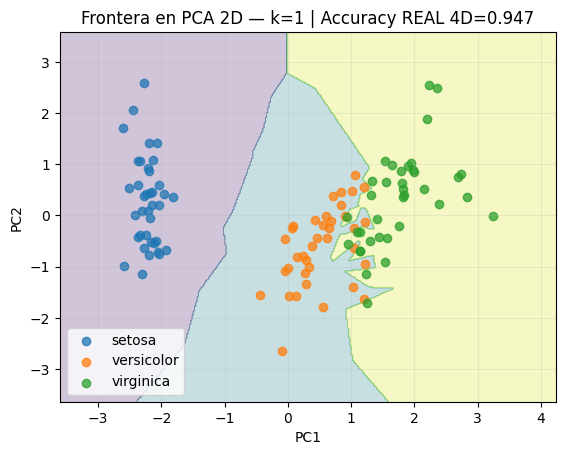

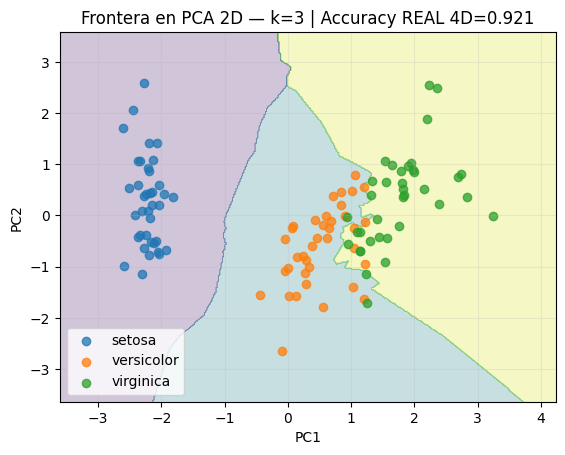

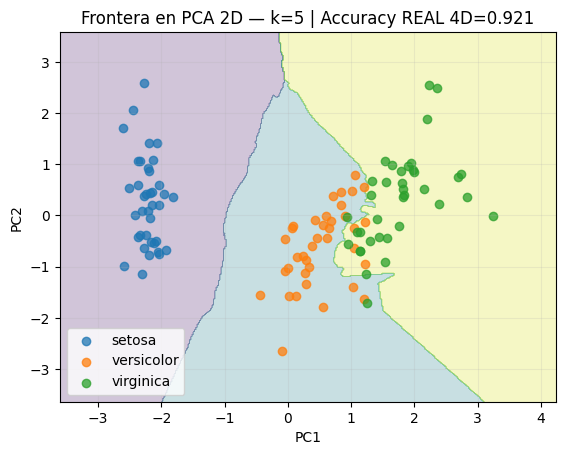

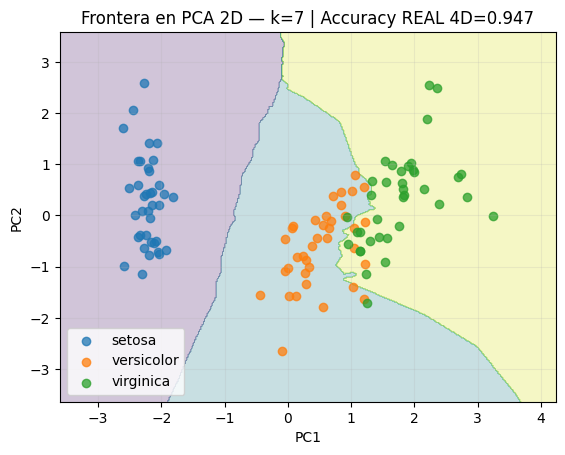

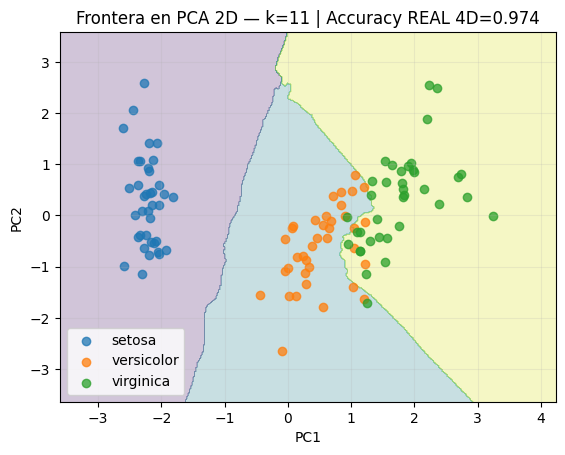

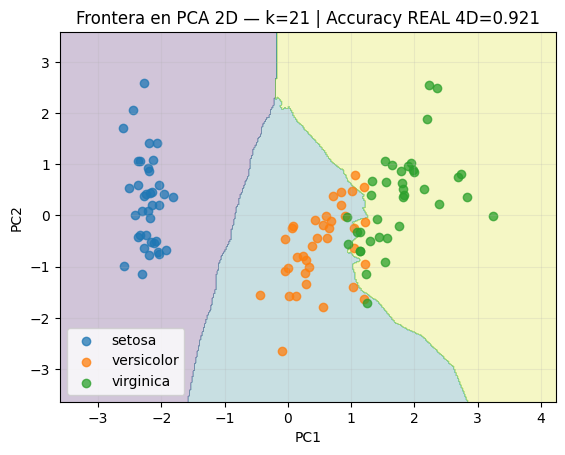

,k,accuracy_4D_real
0,1,0.947368
1,3,0.921053
2,5,0.921053
3,7,0.947368
4,11,0.973684
5,21,0.921053


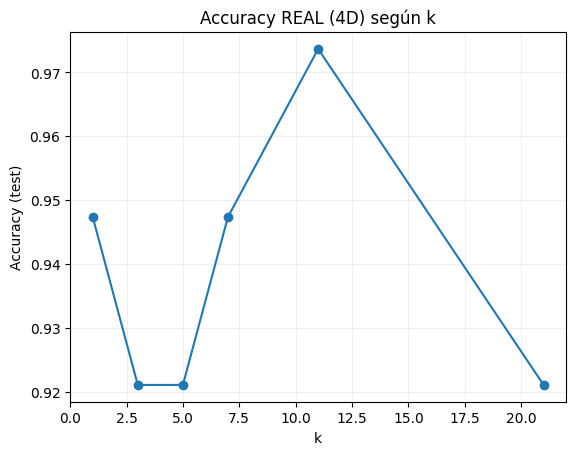

In [13]:
print("9) Efecto de k (accuracy REAL 4D + frontera VISUAL 2D)")

k_values = [1, 3, 5, 7, 11, 21]

rows = []
for k_try in k_values:
    m4 = KNeighborsClassifier(n_neighbors=k_try).fit(X_train_s, y_train)
    acc4 = accuracy_score(y_test, m4.predict(X_test_s))

    m2 = KNeighborsClassifier(n_neighbors=k_try).fit(X_train_pca, y_train)

    rows.append({"k": k_try, "accuracy_4D_real": acc4})

    plot_decision_boundary_2d(
        m2, X_train_pca, y_train,
        title_text=f"Frontera en PCA 2D — k={k_try} | Accuracy REAL 4D={acc4:.3f}"
    )

results = pd.DataFrame(rows)
display(results)

plt.figure()
plt.plot(results["k"], results["accuracy_4D_real"], marker="o")
plt.title("Accuracy REAL (4D) según k")
plt.xlabel("k")
plt.ylabel("Accuracy (test)")
plt.grid(True, alpha=0.2)
plt.show()



### 10) BONUS: KNN manual (distancias) en 4D


In [14]:
print("10) BONUS: KNN manual en 4D (distancias y voto)")

def knn_manual_predict(X_train_s, y_train, point, k):
    dist = np.sqrt(np.sum((X_train_s - point) ** 2, axis=1))
    nearest = np.argsort(dist)[:k]
    votes = y_train[nearest]
    pred = np.bincount(votes).argmax()
    return pred, dist[nearest], nearest, votes

pred_m, dists, neigh_idx, votes = knn_manual_predict(X_train_s, y_train, point4d, k)

print("Punto consulta (4D estandarizado):", point4d)
print("Predicción manual:", iris.target_names[pred_m])
print("\nVecinos (distancia, clase):")
for di, v in sorted(zip(dists, votes), key=lambda t: t[0]):
    print(f" - dist={di:.3f} | clase={iris.target_names[v]}")



10) BONUS: KNN manual en 4D (distancias y voto)
Punto consulta (4D estandarizado): [-1.73958301  0.30321165 -1.38772616 -1.295856  ]
Predicción manual: setosa

Vecinos (distancia, clase):
 - dist=0.242 | clase=setosa
 - dist=0.346 | clase=setosa
 - dist=0.353 | clase=setosa
 - dist=0.391 | clase=setosa
 - dist=0.499 | clase=setosa
 - dist=0.530 | clase=setosa
 - dist=0.549 | clase=setosa


### 8) Más ejemplos: Vecinos más cercanos (visual en PCA 2D) + predicción real 4D


In [15]:
print("8) MÁS EJEMPLOS: Vecinos (PCA 2D) + Predicción REAL (KNN 4D)")

def plot_neighbors_2d(knn_model_2d, X_train_2d, y_train, point_2d, k,
                      subtitle="", show_lines=True):
    distances, indices = knn_model_2d.kneighbors([point_2d], n_neighbors=k, return_distance=True)
    idx = indices[0]
    d = distances[0]
    pred2d = knn_model_2d.predict([point_2d])[0]

    plt.figure()
    for c in np.unique(y_train):
        plt.scatter(X_train_2d[y_train==c, 0], X_train_2d[y_train==c, 1],
                    alpha=0.28, label=iris.target_names[c])

    # vecinos
    plt.scatter(X_train_2d[idx, 0], X_train_2d[idx, 1],
                s=160, facecolors="none", edgecolors="black", linewidths=2,
                label="Vecinos")

    # punto consulta
    plt.scatter(point_2d[0], point_2d[1], s=220, marker="X", label="Punto consulta")

    if show_lines:
        for i, di in zip(idx, d):
            plt.plot([point_2d[0], X_train_2d[i, 0]],
                     [point_2d[1], X_train_2d[i, 1]],
                     linewidth=1, alpha=0.45)

    plt.title(f"Vecinos en PCA 2D (k={k}) — Predicción 2D: {iris.target_names[pred2d]}\n{subtitle}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

def describe_point(idx_test):
    """Devuelve info del punto test idx_test para comparar 4D y 2D."""
    point4d = X_test_s[idx_test]
    point2d = X_test_pca[idx_test]
    true_label = y_test[idx_test]

    pred4d = knn4d.predict([point4d])[0]
    pred2d = knn2d.predict([point2d])[0]

    return {
        "idx_test": idx_test,
        "true": true_label,
        "pred4d": pred4d,
        "pred2d": pred2d,
        "point4d": point4d,
        "point2d": point2d
    }

def show_examples(indices, title_text, show_lines=True):
    print(title_text)
    rows = []
    for idx_test in indices:
        info = describe_point(idx_test)

        rows.append({
            "idx_test": info["idx_test"],
            "real": iris.target_names[info["true"]],
            "pred_4D_real": iris.target_names[info["pred4d"]],
            "pred_2D_visual": iris.target_names[info["pred2d"]],
            "4D_correct": info["pred4d"] == info["true"],
            "2D_matches_4D": info["pred2d"] == info["pred4d"]
        })

        subtitle = (
            f"Real: {iris.target_names[info['true']]} | "
            f"KNN 4D: {iris.target_names[info['pred4d']]} | "
            f"KNN 2D: {iris.target_names[info['pred2d']]} | "
            f"idx_test={info['idx_test']}"
        )

        plot_neighbors_2d(
            knn2d, X_train_pca, y_train,
            info["point2d"], k,
            subtitle=subtitle,
            show_lines=show_lines
        )

    display(pd.DataFrame(rows))



8) MÁS EJEMPLOS: Vecinos (PCA 2D) + Predicción REAL (KNN 4D)


### A) Ejemplos aleatorios (buenos para “ver de todo”)


A) Ejemplos aleatorios del conjunto test (6 puntos)


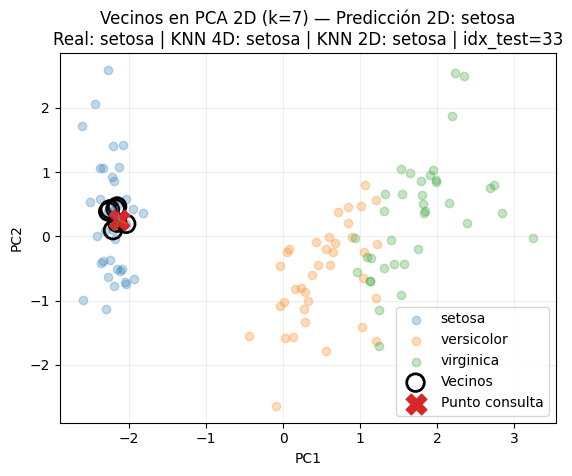

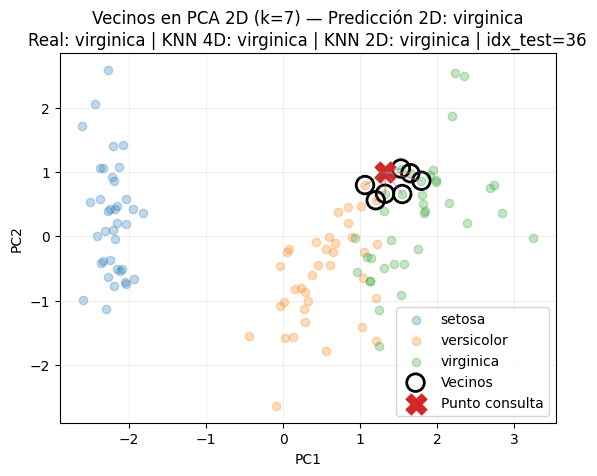

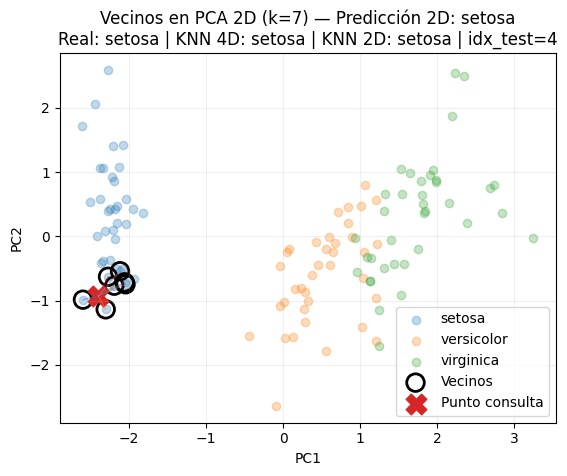

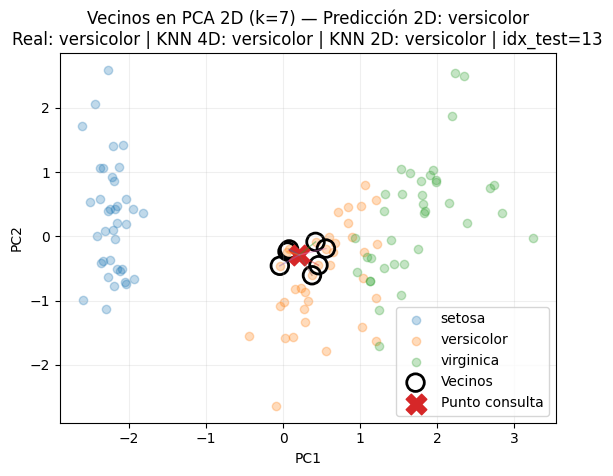

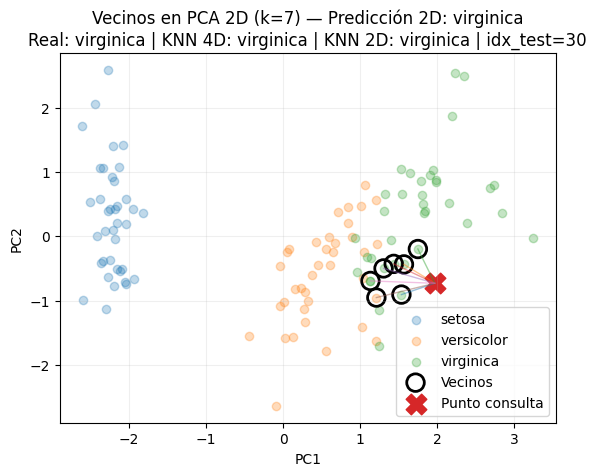

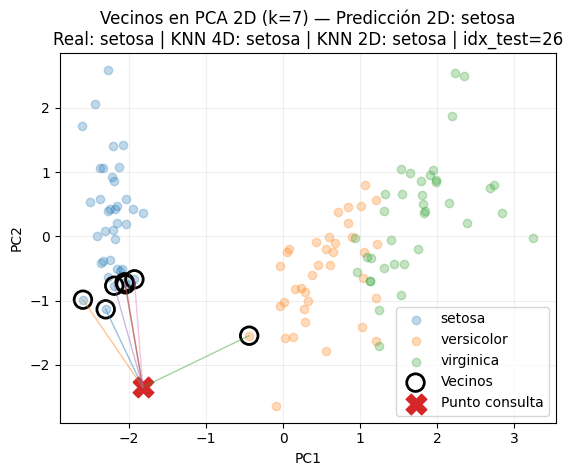

,idx_test,real,pred_4D_real,pred_2D_visual,4D_correct,2D_matches_4D
0,33,setosa,setosa,setosa,True,True
1,36,virginica,virginica,virginica,True,True
2,4,setosa,setosa,setosa,True,True
3,13,versicolor,versicolor,versicolor,True,True
4,30,virginica,virginica,virginica,True,True
5,26,setosa,setosa,setosa,True,True


In [16]:
np.random.seed(42)
random_idxs = np.random.choice(len(X_test_s), size=6, replace=False)
show_examples(
    random_idxs,
    "A) Ejemplos aleatorios del conjunto test (6 puntos)",
    show_lines=True
)



### B) Casos donde el KNN REAL (4D) falla (si existen)


B) Casos donde el KNN REAL (4D) falla (mostrando 2)


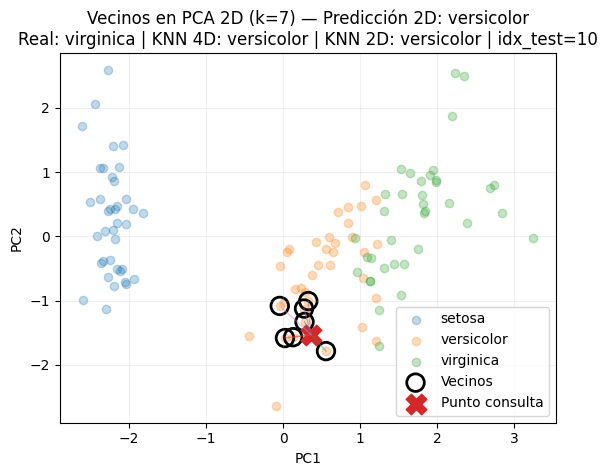

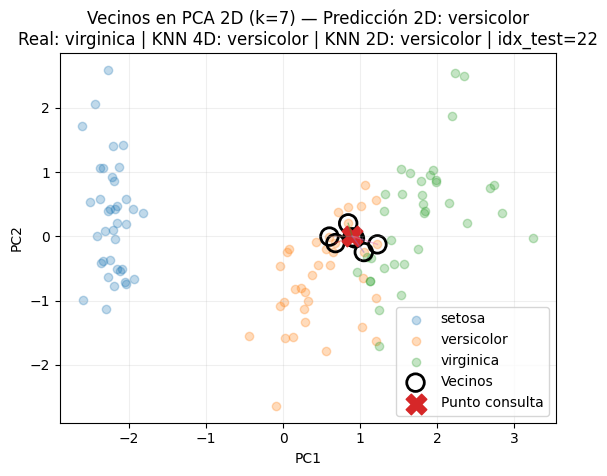

,idx_test,real,pred_4D_real,pred_2D_visual,4D_correct,2D_matches_4D
0,10,virginica,versicolor,versicolor,False,True
1,22,virginica,versicolor,versicolor,False,True


In [17]:
errors_4d = np.where(knn4d.predict(X_test_s) != y_test)[0]
if len(errors_4d) == 0:
    print("B) KNN 4D: No hay fallos en test con este split/k (perfecto)")
else:
    show_examples(
        errors_4d[:6],
        f"B) Casos donde el KNN REAL (4D) falla (mostrando {min(6, len(errors_4d))})",
        show_lines=True
    )



### C) Casos donde KNN 2D (PCA) y KNN 4D discrepan


In [18]:
#    (MUY didáctico para explicar la pérdida de info al proyectar a 2D)


C) Discrepancias 2D vs 4D (mostrando 2 casos)


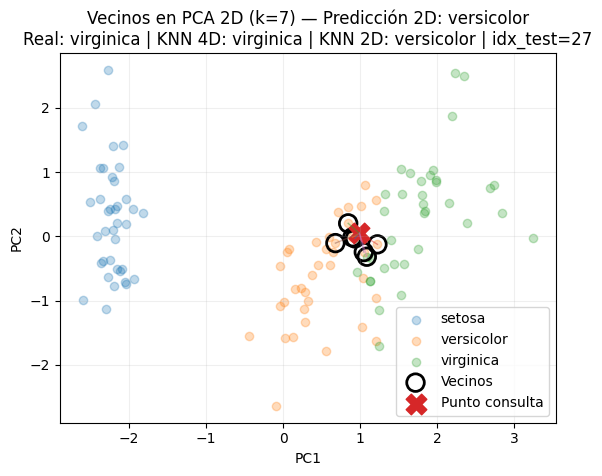

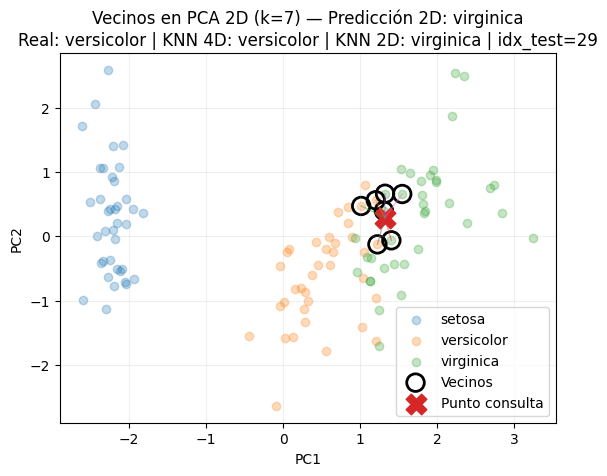

,idx_test,real,pred_4D_real,pred_2D_visual,4D_correct,2D_matches_4D
0,27,virginica,virginica,versicolor,True,False
1,29,versicolor,versicolor,virginica,True,False


In [19]:
pred4d_all = knn4d.predict(X_test_s)
pred2d_all = knn2d.predict(X_test_pca)

disagree = np.where(pred4d_all != pred2d_all)[0]

if len(disagree) == 0:
    print("C) No hay discrepancias entre 2D y 4D (poco común pero puede pasar)")
else:
    show_examples(
        disagree[:8],
        f"C) Discrepancias 2D vs 4D (mostrando {min(8, len(disagree))} casos)",
        show_lines=True
    )



### D) Casos “cerca de la frontera” (heurística):


In [20]:
#    puntos donde la probabilidad máxima del KNN 2D es baja
#    (si el modelo soporta predict_proba)


D) Casos cerca de la frontera (KNN 2D con menor confianza)


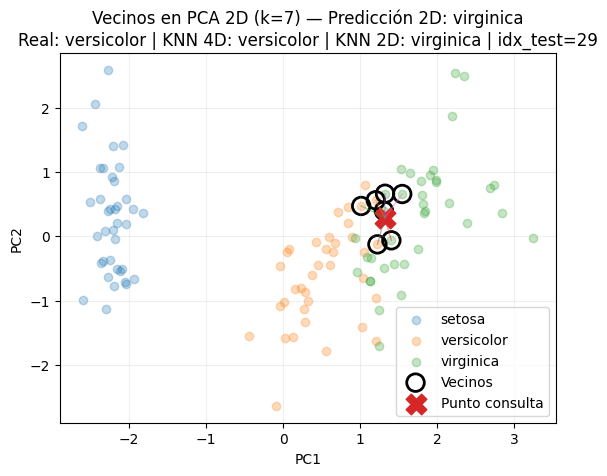

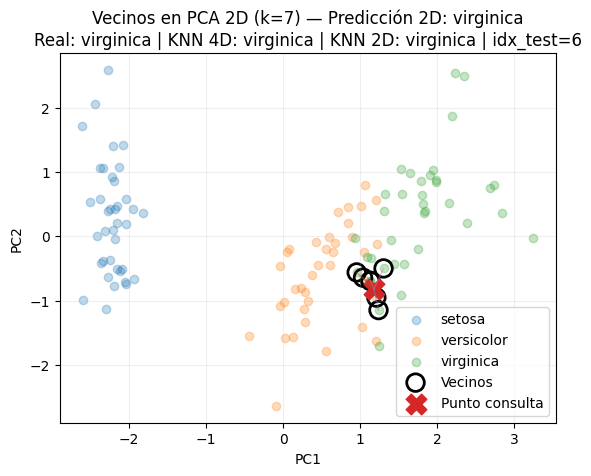

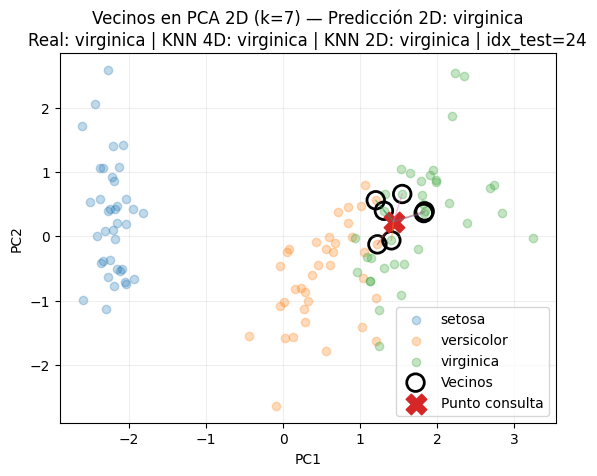

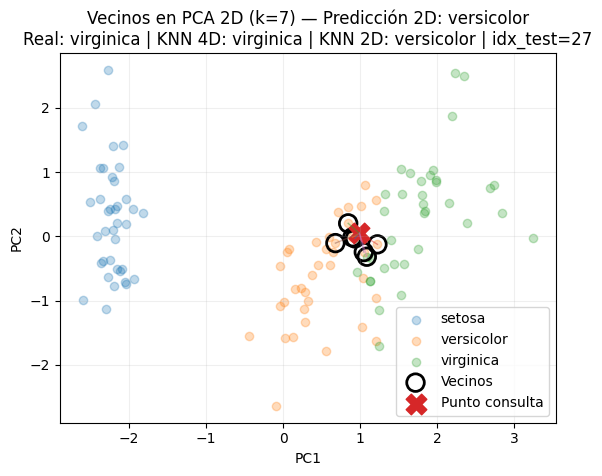

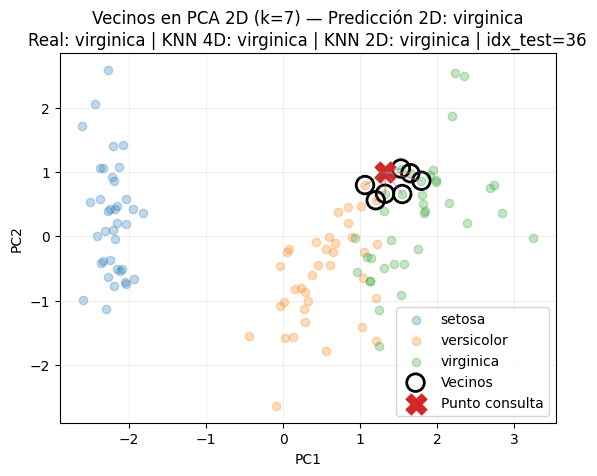

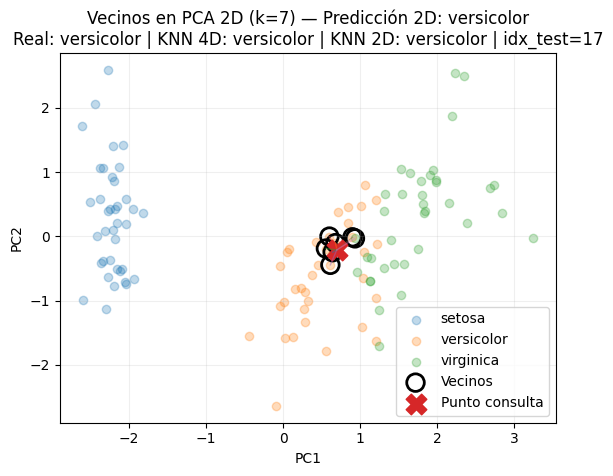

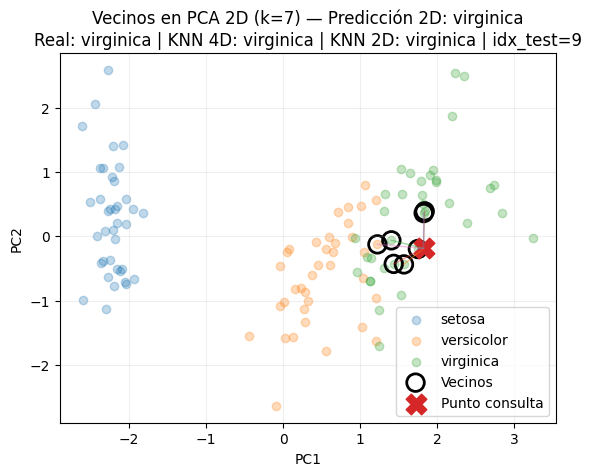

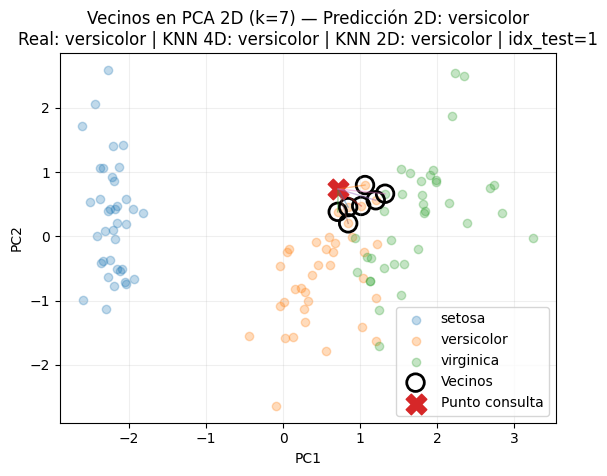

,idx_test,real,pred_4D_real,pred_2D_visual,4D_correct,2D_matches_4D
0,29,versicolor,versicolor,virginica,True,False
1,6,virginica,virginica,virginica,True,True
2,24,virginica,virginica,virginica,True,True
3,27,virginica,virginica,versicolor,True,False
4,36,virginica,virginica,virginica,True,True
5,17,versicolor,versicolor,versicolor,True,True
6,9,virginica,virginica,virginica,True,True
7,1,versicolor,versicolor,versicolor,True,True


In [21]:
if hasattr(knn2d, "predict_proba"):
    proba2d = knn2d.predict_proba(X_test_pca)
    confidence = proba2d.max(axis=1)
    borderline = np.argsort(confidence)[:8]  # los menos confiados

    show_examples(
        borderline,
        "D) Casos cerca de la frontera (KNN 2D con menor confianza)",
        show_lines=True
    )